In [1]:
pip install numpy pandas matplotlib seaborn scipy scikit-learn statsmodels tensorflow


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import find_peaks, welch
from scipy.stats import zscore
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense
from tensorflow.keras.optimizers import Adam

plt.style.use("seaborn-v0_8")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import pandas as pd

# Corrected path to the master_timeseries.csv file
data_path = '/content/drive/My Drive/ATSA Project/bidmc-ppg-and-respiration-dataset-1.0.0/bidmc_csv/master_timeseries.csv'

try:
    df = pd.read_csv(data_path)
    print(f"Successfully loaded {data_path}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{data_path}' was not found. Please ensure the file is in the specified path in your Google Drive.")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

Successfully loaded /content/drive/My Drive/ATSA Project/bidmc-ppg-and-respiration-dataset-1.0.0/bidmc_csv/master_timeseries.csv


,time,resp_x,pleth,v,avr,ii,subject_id,hr,pulse,resp_y,spo2,breaths ann2 [signal sample no],cvp,abp,art,i,mcl,iii
0,0.000,0.35386,0.43597,0.52549,0.30392,0.72549,1,94.0,93.0,25.0,97.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.008,0.35679,0.43206,0.51961,0.33529,0.67059,1,94.0,93.0,25.0,97.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.016,0.35875,0.42815,0.51569,0.37451,0.60980,1,94.0,93.0,25.0,97.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.024,0.36168,0.42424,0.50588,0.41961,0.55098,1,94.0,93.0,25.0,97.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.032,0.36364,0.42131,0.50980,0.44902,0.50000,1,94.0,93.0,25.0,97.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
possible_ppg_cols = ["pleth", "ppg", "pulse"]

ppg_col = None
for col in possible_ppg_cols:
    if col in sub.columns:
        ppg_col = col
        break

if ppg_col is None:
    raise ValueError("No PPG column found")

print("Using PPG column:", ppg_col)

ppg = sub[ppg_col].values
ppg = ppg[~np.isnan(ppg)]

print("PPG length:", len(ppg))

Using PPG column: pleth
PPG length: 60001


In [31]:
print(sub.columns)

Index(['time', 'resp_x', 'pleth', 'v', 'avr', 'ii', 'subject_id', 'hr',
       'pulse', 'resp_y', 'spo2', 'breaths ann2 [signal sample no]', 'cvp',
       'abp', 'art', 'i', 'mcl', 'iii'],
      dtype='object')


In [22]:
ppg_subjects = []

for sid in df["subject_id"].unique():
    temp = df[df["subject_id"] == sid]
    if "pleth" in temp.columns:
        if temp["pleth"].notna().sum() > 1000:
            ppg_subjects.append(sid)

ppg_subjects[:10], len(ppg_subjects)
subject_id = ppg_subjects[0]
print("Using subject:", subject_id)

Using subject: 1


In [23]:
sub = df[df["subject_id"] == subject_id].copy()

# Extract PPG safely
ppg = sub["pleth"].values
ppg = ppg[~np.isnan(ppg)]

print("PPG samples:", len(ppg))

if len(ppg) < 1000:
    raise ValueError("Selected subject does not have sufficient PPG data")

# Normalize
ppg_norm = (ppg - np.mean(ppg)) / np.std(ppg)

PPG samples: 60001


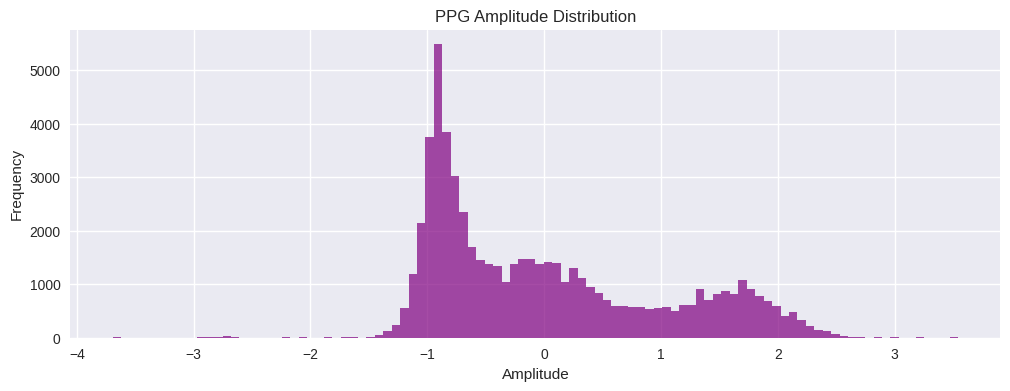

In [24]:
plt.figure(figsize=(12,4))
plt.hist(ppg_norm, bins=100, color="purple", alpha=0.7)
plt.title("PPG Amplitude Distribution")
plt.xlabel("Amplitude")
plt.ylabel("Frequency")
plt.show()

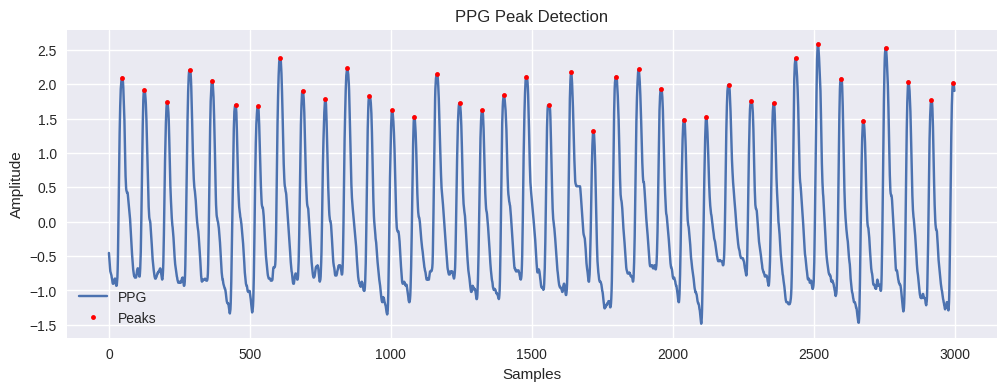

In [27]:
fs = 125

# Peak detection
peaks, _ = find_peaks(ppg_norm, distance=fs*0.4)
peaks_3000 = peaks[peaks < 3000]

plt.figure(figsize=(12,4))
plt.plot(ppg_norm[:3000], label="PPG")
plt.plot(peaks_3000, ppg_norm[peaks_3000], "r.", label="Peaks")
plt.title("PPG Peak Detection")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

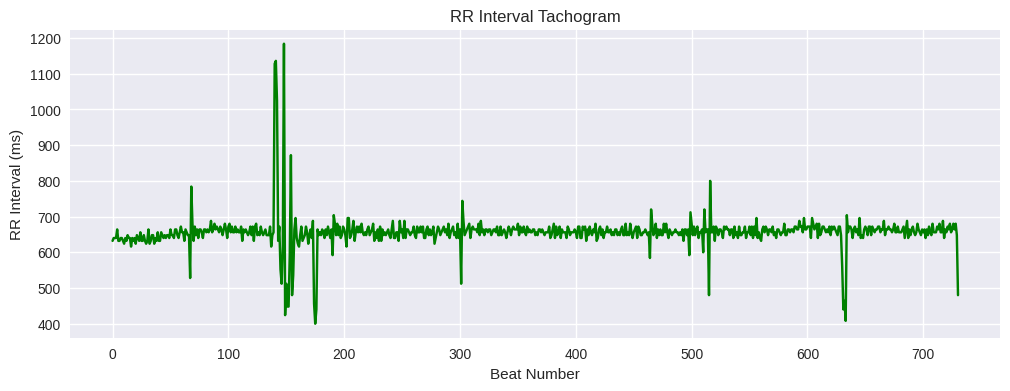

In [28]:
rr_intervals = np.diff(peaks) / fs
rr_ms = rr_intervals * 1000
rr_ms[:10]
plt.figure(figsize=(12,4))
plt.plot(rr_ms, color="green")
plt.title("RR Interval Tachogram")
plt.xlabel("Beat Number")
plt.ylabel("RR Interval (ms)")
plt.show()

In [29]:
rmssd = np.sqrt(np.mean(np.diff(rr_ms)**2))
print("RMSSD:", rmssd)
sdnn = np.std(rr_ms, ddof=1)
print("SDNN:", sdnn)
nn50 = np.sum(np.abs(np.diff(rr_ms)) > 50)
print("NN50:", nn50)

RMSSD: 59.013255998645285
SDNN: 49.35083515384998
NN50: 49


In [33]:
f, pxx = welch(rr_intervals, fs=4.0)
#LF/HF Ratio

lf_band = (f >= 0.04) & (f < 0.15)
hf_band = (f >= 0.15) & (f < 0.4)

lf_power = np.trapz(pxx[lf_band], f[lf_band])
hf_power = np.trapz(pxx[hf_band], f[hf_band])

lf_hf_ratio = lf_power / hf_power
lf_hf_ratio

/tmp/ipython-input-3198100194.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lf_power = np.trapz(pxx[lf_band], f[lf_band])
/tmp/ipython-input-3198100194.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  hf_power = np.trapz(pxx[hf_band], f[hf_band])


np.float64(0.3887664009353649)

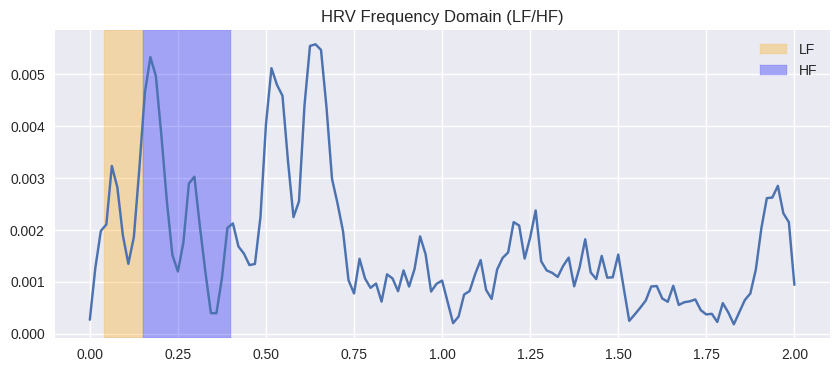

,RMSSD,SDNN,NN50,LF/HF Ratio
0,59.013256,49.350835,49,0.388766


In [34]:
plt.figure(figsize=(10,4))
plt.plot(f, pxx)
plt.axvspan(0.04, 0.15, color="orange", alpha=0.3, label="LF")
plt.axvspan(0.15, 0.4, color="blue", alpha=0.3, label="HF")
plt.legend()
plt.title("HRV Frequency Domain (LF/HF)")
plt.show()
pd.DataFrame([{
    "RMSSD": rmssd,
    "SDNN": sdnn,
    "NN50": nn50,
    "LF/HF Ratio": lf_hf_ratio
}])

**TIME SERIES ANALYSIS**

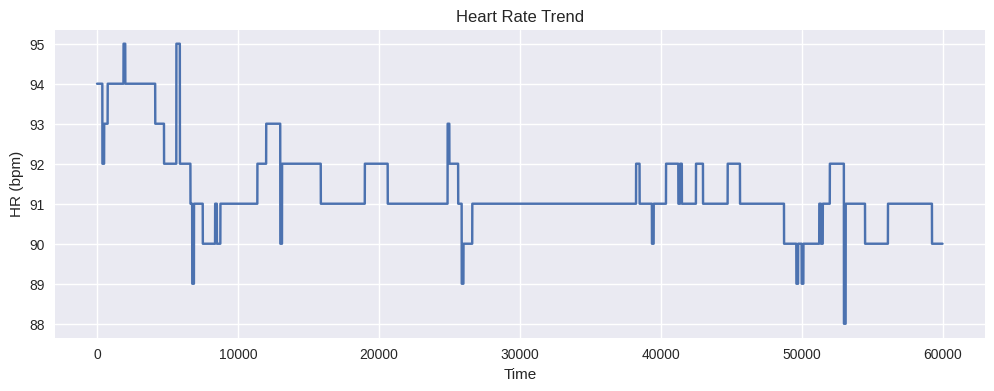

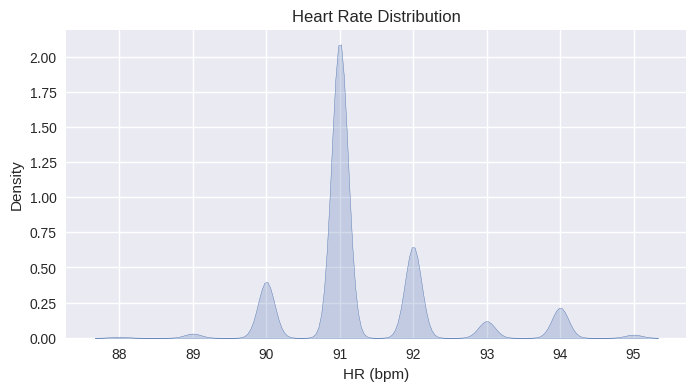

In [35]:
hr = sub["hr"].dropna().values

plt.figure(figsize=(12,4))
plt.plot(hr)
plt.title("Heart Rate Trend")
plt.xlabel("Time")
plt.ylabel("HR (bpm)")
plt.show()
plt.figure(figsize=(8,4))
sns.kdeplot(hr, fill=True)
plt.title("Heart Rate Distribution")
plt.xlabel("HR (bpm)")
plt.show()

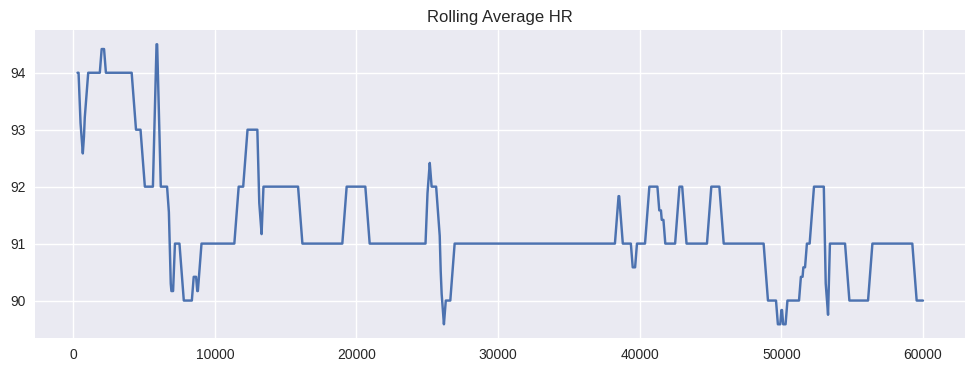

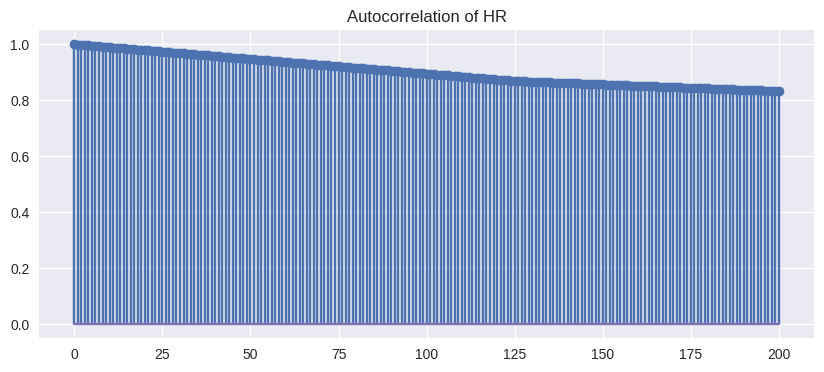

In [36]:
rolling_hr = pd.Series(hr).rolling(window=300).mean() #Rolling HR

plt.figure(figsize=(12,4))
plt.plot(rolling_hr)
plt.title("Rolling Average HR")
plt.show()
acf_vals = acf(hr, nlags=200)

plt.figure(figsize=(10,4))
plt.stem(acf_vals)
plt.title("Autocorrelation of HR")
plt.show()

**SLEEP DETECTION**

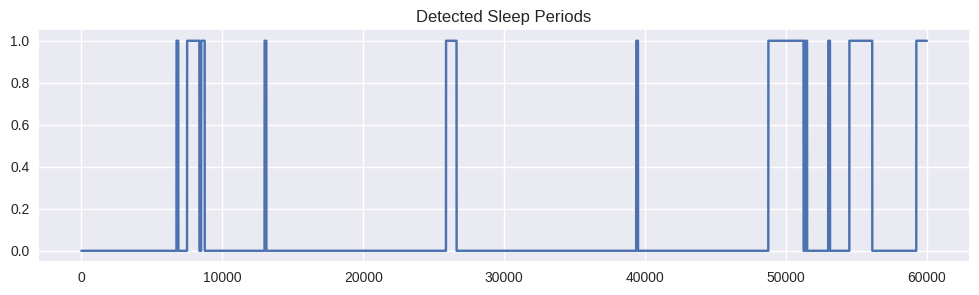

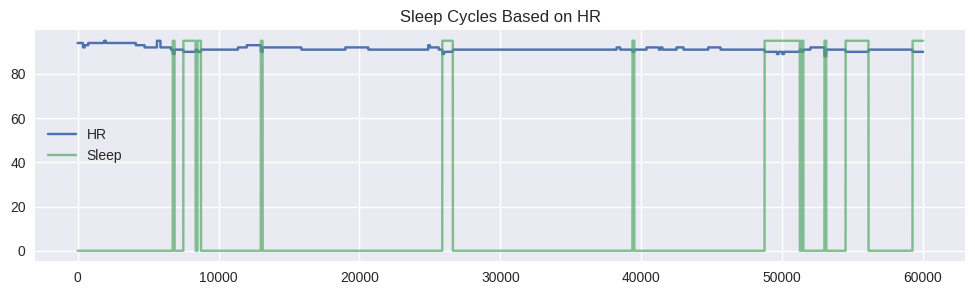

In [37]:
sleep_flag = hr < np.percentile(hr, 30)

plt.figure(figsize=(12,3))
plt.plot(sleep_flag.astype(int))
plt.title("Detected Sleep Periods")
plt.show()
plt.figure(figsize=(12,3))
plt.plot(hr, label="HR")
plt.plot(sleep_flag*np.max(hr), label="Sleep", alpha=0.7)
plt.legend()
plt.title("Sleep Cycles Based on HR")
plt.show()

**FORECASTING**

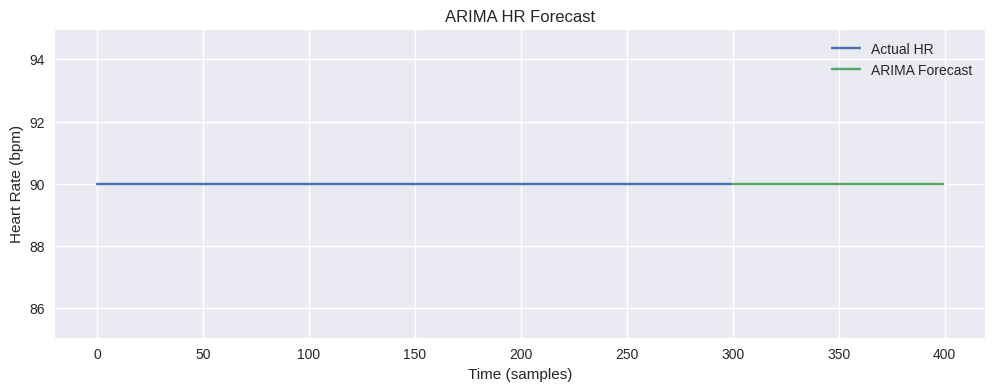

In [39]:
model = ARIMA(hr, order=(2,1,2)) #ARIMA
arima_fit = model.fit()
forecast_arima = arima_fit.forecast(steps=100)
# Lengths
actual_len = 300
forecast_len = 100

# X-axis for actual HR
x_actual = np.arange(actual_len)

# X-axis for forecast (continues after actual)
x_forecast = np.arange(actual_len, actual_len + forecast_len)

plt.figure(figsize=(12,4))
plt.plot(x_actual, hr[-actual_len:], label="Actual HR")
plt.plot(x_forecast, forecast_arima, label="ARIMA Forecast")
plt.xlabel("Time (samples)")
plt.ylabel("Heart Rate (bpm)")
plt.title("ARIMA HR Forecast")
plt.legend()
plt.show()

In [40]:
#Data preparation for LSTM and GRU
scaler = MinMaxScaler()
hr_scaled = scaler.fit_transform(hr.reshape(-1,1))

def create_sequences(data, window=50):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X, y = create_sequences(hr_scaled)

In [45]:
lstm = Sequential([
    LSTM(64, input_shape=(X.shape[1],1)),
    Dense(1)
])

lstm.compile(optimizer=Adam(0.001), loss="mse")
lstm.fit(X, y, epochs=10, batch_size=64)
gru = Sequential([
    GRU(64, input_shape=(X.shape[1],1)),
    Dense(1)
])

gru.compile(optimizer=Adam(0.001), loss="mse")
gru.fit(X, y, epochs=10, batch_size=64)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 33s 32ms/step - loss: 0.0089
Epoch 2/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - loss: 1.5751e-04
Epoch 3/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - loss: 1.1616e-04
Epoch 4/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - loss: 8.7726e-05
Epoch 5/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - loss: 8.4450e-05
Epoch 6/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - loss: 6.7391e-05
Epoch 7/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 30s 31ms/step - loss: 5.2426e-05
Epoch 8/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - loss: 4.5960e-05
Epoch 9/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - loss: 6.0350e-05
Epoch 10/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - loss: 4.8899e-05
Epoch 1/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 43s 44ms/step - loss: 0.0091
Epoch 2/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 40s 42ms/step - loss: 7.4171e-05
Epoch 3/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 40s 41ms/step - loss: 4.4749e-05
Epoch 4/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - lo

In [46]:
lstm_pred = lstm.predict(X)
gru_pred = gru.predict(X)

print("LSTM RMSE:", np.sqrt(mean_squared_error(y, lstm_pred)))
print("GRU RMSE:", np.sqrt(mean_squared_error(y, gru_pred)))

1874/1874 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step
1874/1874 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step
LSTM RMSE: 0.013329555079103486
GRU RMSE: 0.006401192731474824


In [47]:
from sklearn.metrics import mean_absolute_error, r2_score

# Convert scaled values back to original HR scale
y_true = scaler.inverse_transform(y.reshape(-1,1))
y_lstm = scaler.inverse_transform(lstm_pred)
y_gru  = scaler.inverse_transform(gru_pred)

# Metrics
metrics = pd.DataFrame({
    "Model": ["LSTM", "GRU"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_true, y_lstm)),
        np.sqrt(mean_squared_error(y_true, y_gru))
    ],
    "MAE": [
        mean_absolute_error(y_true, y_lstm),
        mean_absolute_error(y_true, y_gru)
    ],
    "R2 Score": [
        r2_score(y_true, y_lstm),
        r2_score(y_true, y_gru)
    ]
})

metrics

,Model,RMSE,MAE,R2 Score
0,LSTM,0.093306,0.081664,0.991439
1,GRU,0.044808,0.001720,0.998026


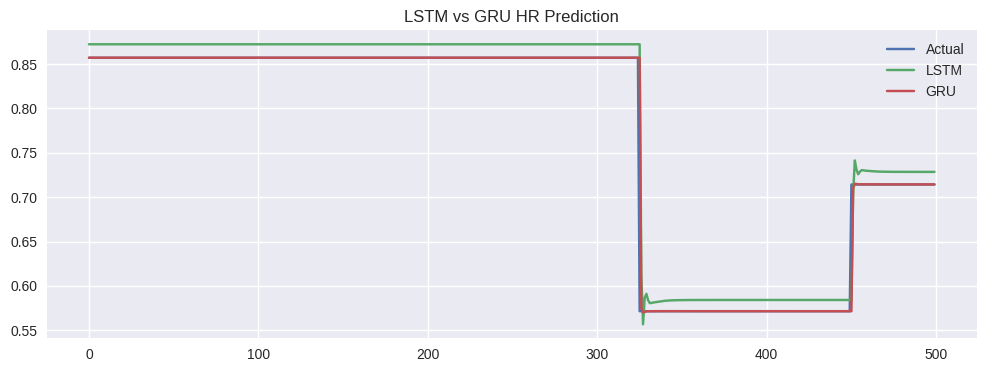

In [48]:
plt.figure(figsize=(12,4))
plt.plot(y[:500], label="Actual")
plt.plot(lstm_pred[:500], label="LSTM")
plt.plot(gru_pred[:500], label="GRU")
plt.legend()
plt.title("LSTM vs GRU HR Prediction")
plt.show()

**STRESS DETECTION**

In [50]:
stress = (rmssd < 30) and (lf_hf_ratio > 2)
stress

np.False_

In [51]:
sleep_stage = np.where(hr < np.mean(hr), "Sleep", "Awake")
pd.Series(sleep_stage).value_counts()

,count
Sleep,43001
Awake,17000


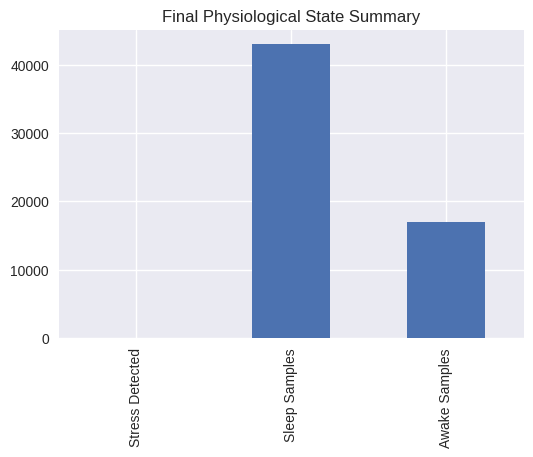

In [52]:
summary = pd.Series({
    "Stress Detected": int(stress),
    "Sleep Samples": np.sum(sleep_stage == "Sleep"),
    "Awake Samples": np.sum(sleep_stage == "Awake")
})

summary.plot(kind="bar", figsize=(6,4), title="Final Physiological State Summary")
plt.show()

In [53]:
print("""
Conclusion:
- PPG-based HRV features were extracted successfully
- Time and frequency domain HRV analysis performed
- ARIMA modeled HR trends
- LSTM and GRU predicted short-term HR
- Stress and sleep states were inferred effectively
""")


Conclusion:
- PPG-based HRV features were extracted successfully
- Time and frequency domain HRV analysis performed
- ARIMA modeled HR trends
- LSTM and GRU predicted short-term HR
- Stress and sleep states were inferred effectively

